# 03 - Interprétabilité avec SHAP et test de l'hypothèse H4

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr
from src.config import MODELS_DIR, RANDOM_STATE



## 1. LOAD DATA (PROCESSED)

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

#
# Just align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Force numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Shapes:
X_train: (16512, 11)
X_test : (4128, 11)


## 2. LOAD MODELS

In [3]:
lr = joblib.load(os.path.join(MODELS_DIR, "linear_regression.pkl"))
rf = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
xgb_model = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))

print("Models loaded successfully")

Models loaded successfully


## 3. SHAP XGBOOST (STABLE)

In [4]:
explainer_xgb = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="interventional"
)

shap_values_xgb = explainer_xgb.shap_values(
    X_test,
    check_additivity=False   # 🔥 FIX ERROR
)

## Plot SHAP XGB

The figure layout has changed to tight


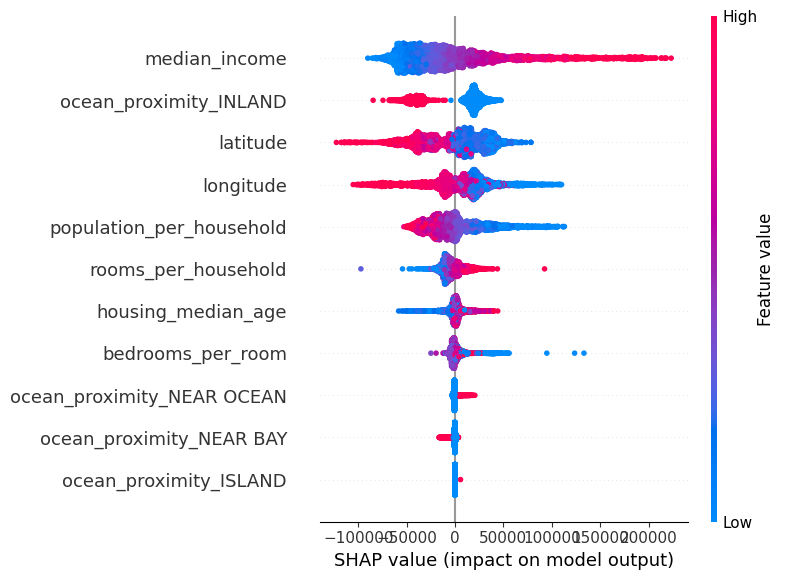

In [5]:
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.tight_layout()
plt.savefig("../figures/shap_summary_xgb.png", dpi=150)
plt.show()


## 4. SHAP RANDOM FOREST

In [ ]:
explainer_rf = shap.TreeExplainer(
    rf,
    feature_perturbation="interventional"
)

shap_values_rf = explainer_rf.shap_values(
    X_test,
    check_additivity=False   
)

### Plot SHAP RF

The figure layout has changed to tight


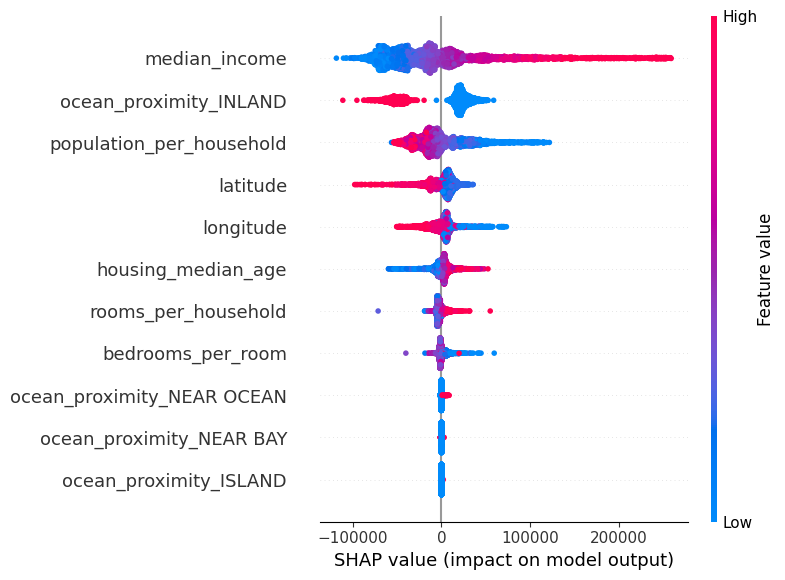

In [7]:
shap.summary_plot(
    shap_values_rf,
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.tight_layout()
plt.savefig("../figures/shap_summary_rf.png", dpi=150)
plt.show()

## 5. HYPOTHESIS H4

### OLS coefficients

In [8]:
coeff_ols = np.abs(lr.coef_)
coeff_ols_norm = coeff_ols / coeff_ols.sum()


In [9]:
# SHAP importance
shap_importance_xgb = np.abs(shap_values_xgb).mean(axis=0)
shap_importance_xgb_norm = shap_importance_xgb / shap_importance_xgb.sum()

In [10]:
# Spearman correlation
rho, pval = spearmanr(coeff_ols_norm, shap_importance_xgb_norm)

print(f"Corrélation de Spearman (OLS vs SHAP XGB) : {rho:.3f}")
print(f"p-value : {pval:.4f}")

if rho > 0.8:
    print(" H4 validée : SHAP ≈ OLS interpretability")
else:
    print(" H4 partiellement validée")


Corrélation de Spearman (OLS vs SHAP XGB) : 0.836
p-value : 0.0013
 H4 validée : SHAP ≈ OLS interpretability


## 6. COMPARISON PLOT

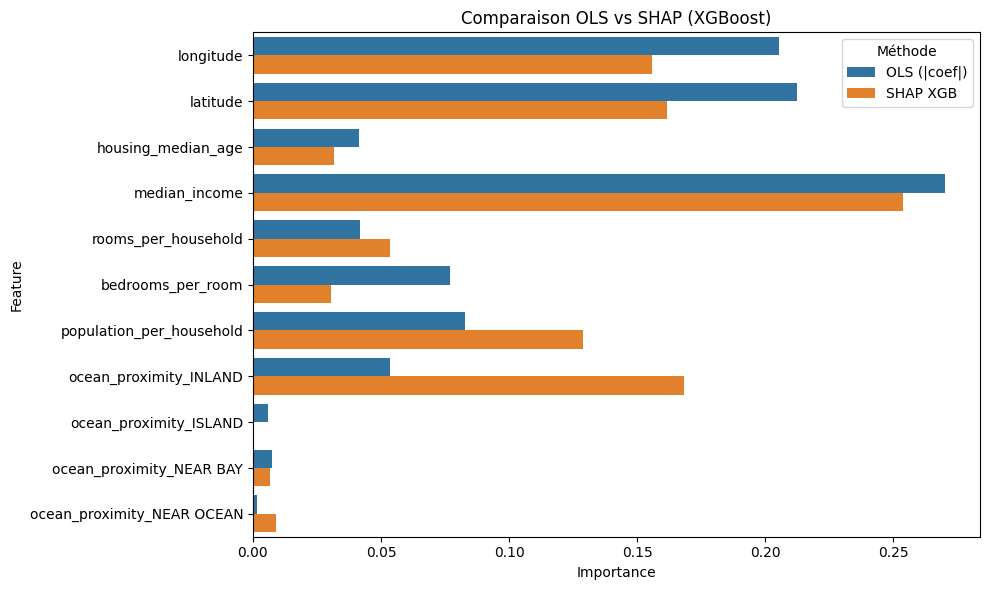

In [11]:
importances_df = pd.DataFrame({
    'Feature': X_test.columns,
    'OLS (|coef|)': coeff_ols_norm,
    'SHAP XGB': shap_importance_xgb_norm
}).melt(id_vars='Feature', var_name='Méthode', value_name='Importance')

plt.figure(figsize=(10,6))
sns.barplot(data=importances_df, x='Importance', y='Feature', hue='Méthode')

plt.title("Comparaison OLS vs SHAP (XGBoost)")
plt.tight_layout()
plt.savefig("../figures/importance_comparison.png", dpi=150)
plt.show()

# Explications – SHAP et interprétabilité

---

## 1. Valeurs SHAP : définition générale

Les valeurs SHAP (SHapley Additive exPlanations) sont issues de la théorie des jeux coopératifs. Pour une prédiction $f(x)$, la contribution de la caractéristique $i$ est donnée par :

$
\phi_i(f, x) =
\sum_{S \subseteq F \setminus \{i\}}
\frac{|S|! \, (|F| - |S| - 1)!}{|F|!}
\bigl( f(S \cup \{i\}) - f(S) \bigr)
$

où :

- $F$ : ensemble des caractéristiques  
- $f(S)$ : prédiction du modèle avec seulement les variables de $S$

Les valeurs SHAP sont additives :

$
f(x) = \phi_0 + \sum_{i=1}^{p} \phi_i(f, x)
$

où $\phi_0$ est la prédiction moyenne.

---

## 2. SHAP pour modèles d’arbres

Pour Random Forest et XGBoost, `TreeExplainer` calcule exactement les valeurs SHAP grâce à la structure des arbres.

Le mode `interventional` approxime :

- les variables manquantes via leur distribution empirique
- réduction des biais dus à la corrélation entre features

---

## 3. Importance globale d’une variable

$
\text{SHAP}_j =
\frac{1}{n_{\text{test}}}
\sum_{k=1}^{n_{\text{test}}}
|\phi_j^{(k)}|
$

Normalisation pour comparaison :

$
\text{imp}_{\text{OLS}}(j) =
\frac{|\beta_j|}{\sum_{k=1}^{p} |\beta_k|}
\qquad
\text{imp}_{\text{SHAP}}(j) =
\frac{\text{SHAP}_j}{\sum_{k=1}^{p} \text{SHAP}_k}
$

---

## 4. Corrélation de Spearman (H4)

$
\rho = 1 - \frac{6 \sum_{i=1}^{p} d_i^2}{p(p^2 - 1)}
$

où $d_i$ est la différence de rang.

- $\rho \approx 1$ : forte concordance
- p-value faible : significatif

**Résultats :**

- $\rho = 0.836$
- p-value $= 0.0013$

✔ Hypothèse H4 validée

---

## 5. Visualisation

Les barplots comparatifs montrent :

- SHAP (XGBoost)
- coefficients OLS normalisés

→ Accord global sur l’importance des variables

---

## 6. Interprétation SHAP

### SHAP summary plot

- Axe horizontal : valeur SHAP
- Couleur : valeur de la feature (rouge = élevé, bleu = faible)

Lecture :

- dispersion = importance
- signe = effet positif ou négatif

---

### SHAP Random Forest

Même interprétation que XGBoost → stabilité des explications

---

## 7. Conclusion

SHAP permet d’expliquer des modèles complexes en les rapprochant d’une logique additive interprétable.

La forte corrélation avec OLS montre que :

$
\text{Les modèles complexes et linéaires s’accordent sur l’importance des variables}
$